In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /data/ceph/hdd/project/node_09/sys_gen_students/2025_2026/p06_indel_glm/repo_jun/InsDelGLM


In [3]:
from pathlib import Path

import torch
from modules.custom_bert import DNABertForMaskedLM
from modules.dna_tokenizer import DNATokenizer

model_dir = "../model/test"

tokenizer = DNATokenizer.from_pretrained(model_dir)
model = DNABertForMaskedLM.from_pretrained(model_dir)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

print("Loaded model from:", Path(model_dir).resolve())
print("Device:", device)
print("Vocab size:", model.config.vocab_size)
print("Mask token id:", tokenizer.mask_token_id)
print("Pad token id:", tokenizer.pad_token_id)
print("Example tokens:", tokenizer("ACGT-")["input_ids"])

/opt/modules/i12g/anaconda/envs/sysgen_p06/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded model from: /data/ceph/hdd/project/node_09/sys_gen_students/2025_2026/p06_indel_glm/repo_jun/InsDelGLM/model/test
Device: cpu
Vocab size: 9
Mask token id: 6
Pad token id: 5
Example tokens: tensor([[7, 0, 2, 3, 1, 4, 8, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 

In [4]:
import numpy as np
import pandas as pd
import torch

# 1) load test set
df = pd.read_parquet("../data/simulated/test.parquet")
seqs = df["sequences"].tolist()
print("n_test:", len(seqs))
print("example seq:", seqs[0][:80])

# 2) load motifs
with open("../data/simulated/motifs.txt") as f:
    motif_a = f.readline().strip()
    motif_b = f.readline().strip()

print("motif_a:", motif_a, "len=", len(motif_a))
print("motif_b:", motif_b, "len=", len(motif_b))

n_test: 2000
example seq: ACAGGG-CGGCGGAGCACTAGGTAGG-TACGAAGATCTTA
motif_a: ACTAGGT len= 7
motif_b: ATCTTA len= 6


In [6]:
mask_id = tokenizer.mask_token_id
pad_id = tokenizer.pad_token_id

# gap token id ( '-' )
gap_id = tokenizer("-")["input_ids"][0][1]

# nucleotide token ids
A_id = tokenizer("A")["input_ids"][0][1]
C_id = tokenizer("C")["input_ids"][0][1]
G_id = tokenizer("G")["input_ids"][0][1]
T_id = tokenizer("T")["input_ids"][0][1]

print(
    "IDs:",
    {
        "A": A_id,
        "C": C_id,
        "G": G_id,
        "T": T_id,
        "-": gap_id,
        "[MASK]": mask_id,
        "[PAD]": pad_id,
    },
)

IDs: {'A': tensor(0), 'C': tensor(2), 'G': tensor(3), 'T': tensor(1), '-': tensor(4), '[MASK]': 6, '[PAD]': 5}


In [25]:
def find_motif_pos(seq, motif):
    return seq.find(motif)


def show_context(seq, start, motif, flank=8):
    """Show motif with left/right flanks for readability."""
    if start < 0:
        return None
    left = seq[max(0, start - flank) : start]
    mid = seq[start : start + len(motif)]
    right = seq[start + len(motif) : start + len(motif) + flank]
    return f"{left}[{mid}]{right}"


def spacing_between_motifs(seq, a_start, motif_a, b_start, motif_b):
    """
    Compute spacing between motif A and motif B.
    - char_spacing: raw character distance from end(A) to start(B)
    - nuc_spacing: distance counting only A/C/G/T (excluding '-')
    """
    a_end = a_start + len(motif_a)
    b_begin = b_start

    if a_start < 0 or b_start < 0:
        return None, None
    if b_begin < a_end:
        return None, None  # overlapping or invalid order

    between = seq[a_end:b_begin]  # substring between motifs
    char_spacing = len(between)
    nuc_spacing = sum(ch in ["A", "C", "G", "T"] for ch in between)  # exclude '-'

    return char_spacing, nuc_spacing


n_show = 10
shown = 0

for s in seqs:
    pa = find_motif_pos(s, motif_a)
    pb = find_motif_pos(s, motif_b)

    # only show sequences where BOTH motifs exist and B is after A
    if pa >= 0 and pb >= 0 and pb > pa:
        char_sp, nuc_sp = spacing_between_motifs(s, pa, motif_a, pb, motif_b)
        if char_sp is None:
            continue

        print(f"\nexample {shown+1}")
        print("FULL SEQUENCE:", s)  # show the entire sequence in one line
        print("motif A start:", pa, "| motif B start:", pb)
        print("A context:", show_context(s, pa, motif_a, flank=10))
        print("B context:", show_context(s, pb, motif_b, flank=10))

        # spacing (A end -> B start)
        print("spacing (chars, includes '-'): ", char_sp)
        print("spacing (nucleotides only, excludes '-'): ", nuc_sp)

        shown += 1
        if shown >= n_show:
            break

print("\nShown:", shown)


example 1
FULL SEQUENCE: ACAGGG-CGGCGGAGCACTAGGTAGG-TACGAAGATCTTA
motif A start: 16 | motif B start: 34
A context: -CGGCGGAGC[ACTAGGT]AGG-TACGAA
B context: GG-TACGAAG[ATCTTA]
spacing (chars, includes '-'):  11
spacing (nucleotides only, excludes '-'):  10

example 2
FULL SEQUENCE: GTCTGCGCACTAGGTAGGTAACGCTATCTTA-TTAAGCTT
motif A start: 8 | motif B start: 25
A context: GTCTGCGC[ACTAGGT]AGGTAACGCT
B context: AGGTAACGCT[ATCTTA]-TTAAGCTT
spacing (chars, includes '-'):  10
spacing (nucleotides only, excludes '-'):  10

example 3
FULL SEQUENCE: GGAGACCACTAGGTAG-CC-CAGCCAATCTTAATAGC-AG
motif A start: 7 | motif B start: 26
A context: GGAGACC[ACTAGGT]AG-CC-CAGC
B context: -CC-CAGCCA[ATCTTA]ATAGC-AG
spacing (chars, includes '-'):  12
spacing (nucleotides only, excludes '-'):  10

example 4
FULL SEQUENCE: GAGACTAGGTATCGGCAAATAATTTTCTCAATCTTACCGC
motif A start: 3 | motif B start: 30
A context: GAG[ACTAGGT]ATCGGCAAAT
B context: AATTTTCTCA[ATCTTA]CCGC
spacing (chars, includes '-'):  20
spacing (nuc

In [19]:
import torch
import torch.nn.functional as F

# --- token ids we care about ---
A_id = tokenizer("A")["input_ids"][0][1]
C_id = tokenizer("C")["input_ids"][0][1]
G_id = tokenizer("G")["input_ids"][0][1]
T_id = tokenizer("T")["input_ids"][0][1]
gap_id = tokenizer("-")["input_ids"][0][1]

mask_id = tokenizer.mask_token_id
pad_id = tokenizer.pad_token_id

VOCAB_IDS = [A_id, C_id, G_id, T_id, gap_id]
VOCAB_CHS = ["A", "C", "G", "T", "-"]


def probs_at_position(sequence: str, pos_char: int, max_length: int = 64):
    """
    Returns model probabilities for A/C/G/T/- at a given character position.
    IMPORTANT: We do NOT insert "[MASK]" into the raw string.
               We mask directly in token ids to avoid DNATokenizer errors.
    """
    # --- bounds check ---
    if pos_char < 0 or pos_char >= len(sequence):
        return None

    # --- tokenize the original sequence (no masking in the string) ---
    enc = tokenizer(sequence, max_length, padding="max_length", return_tensors="pt")
    enc = {k: v.to(device) for k, v in enc.items()}

    input_ids = enc["input_ids"].clone()  # [1, L]
    attn_mask = enc["attention_mask"].clone()  # [1, L]

    # DNATokenizer adds [CLS] at token index 0, so shift by +1
    pos_tok = pos_char + 1
    if pos_tok >= input_ids.shape[1]:
        return None

    # --- mask the token directly in input_ids ---
    input_ids[0, pos_tok] = mask_id

    with torch.no_grad():
        out = model(input_ids=input_ids, attention_mask=attn_mask)

    logits = out.logits if hasattr(out, "logits") else out[0]  # [1, L, V]
    probs_full = F.softmax(logits[0, pos_tok], dim=-1)  # [V]

    # --- return only A/C/G/T/- probabilities ---
    probs = {ch: float(probs_full[_id].item()) for ch, _id in zip(VOCAB_CHS, VOCAB_IDS)}
    return probs

In [20]:
s = seqs[0]

print("Sequence:", s)
print("Length:", len(s))
print("True base at pos 10:", s[10])

probs = probs_at_position(s, pos_char=10)
print("Predicted probs:", probs)

Sequence: ACAGGG-CGGCGGAGCACTAGGTAGG-TACGAAGATCTTA
Length: 40
True base at pos 10: C
Predicted probs: {'A': 0.21722665429115295, 'C': 0.19829176366329193, 'G': 0.24445177614688873, 'T': 0.30624711513519287, '-': 0.03369617834687233}


In [26]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

# --- settings ---
SEQ_LEN = 40  # raw sequence length
MAX_LEN = 64  # tokenizer max length (must be int)
BATCH_SIZE = 64  # adjust for your machine
mask_id = tokenizer.mask_token_id

# --- token ids we care about (A,C,G,T,-) ---
A_id = tokenizer("A")["input_ids"][0][1]
C_id = tokenizer("C")["input_ids"][0][1]
G_id = tokenizer("G")["input_ids"][0][1]
T_id = tokenizer("T")["input_ids"][0][1]
gap_id = tokenizer("-")["input_ids"][0][1]

# Keep these ids on the same device as the model for fast indexing
VOCAB_IDS = torch.tensor(
    [A_id, C_id, G_id, T_id, gap_id], device=device, dtype=torch.long
)
VOCAB_CHS = ["A", "C", "G", "T", "-"]


def mean_probs_heatmap(
    seqs_subset, seq_len=SEQ_LEN, max_len=MAX_LEN, batch_size=BATCH_SIZE
):
    """
    Compute mean predicted probabilities for A/C/G/T/- at each character position.

    For each position p:
      - mask the token at p
      - run the model
      - read probability distribution at that masked token
      - average across sequences

    Returns:
      heat: np.ndarray of shape [seq_len, 5]
    """
    model.eval()

    heat = np.zeros((seq_len, 5), dtype=np.float64)

    # --- helper: iterate mini-batches ---
    def batches(lst, bs):
        for i in range(0, len(lst), bs):
            yield lst[i : i + bs]

    for pos_char in range(seq_len):
        probs_list = []

        for batch_seqs in batches(seqs_subset, batch_size):
            # IMPORTANT: DNATokenizer expects max_length as a POSITIONAL arg
            enc = tokenizer(
                batch_seqs,
                max_len,  # positional max_length (do NOT use max_length=...)
                padding="max_length",
                return_tensors="pt",
            )
            enc = {k: v.to(device) for k, v in enc.items()}

            input_ids = enc["input_ids"].clone()

            # DNATokenizer has [CLS] at token index 0 -> shift by +1
            pos_tok = pos_char + 1
            if pos_tok >= input_ids.shape[1]:
                continue

            # Mask the token id directly (do NOT insert "[MASK]" in raw string)
            input_ids[:, pos_tok] = mask_id

            with torch.no_grad():
                out = model(input_ids=input_ids, attention_mask=enc["attention_mask"])

            logits = out.logits if hasattr(out, "logits") else out[0]  # [B, L, V]

            # Softmax at masked token position
            p = F.softmax(logits[:, pos_tok, :], dim=-1)  # [B, V]
            p5 = p.index_select(dim=-1, index=VOCAB_IDS)  # [B, 5]

            probs_list.append(p5.detach().cpu().numpy())

        if len(probs_list) == 0:
            continue

        all_probs = np.concatenate(probs_list, axis=0)  # [N, 5]
        heat[pos_char] = all_probs.mean(axis=0)

        if (pos_char + 1) % 10 == 0:
            print(f"done {pos_char+1}/{seq_len}")

    return heat


# --- run on a small subset first (fast sanity check) ---
subset = seqs[:200]  # increase later (e.g., 1000)
heat = mean_probs_heatmap(subset)

print("heat shape:", heat.shape)  # expected: (40, 5)

done 10/40
done 20/40
done 30/40
done 40/40
heat shape: (40, 5)


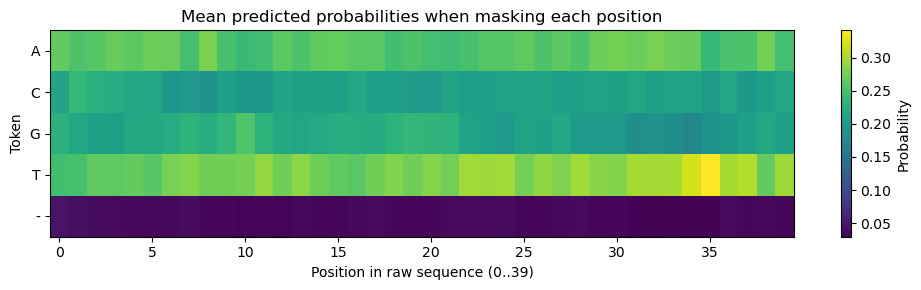

In [27]:
# --- Plot: token probability heatmap (tokens on y-axis, positions on x-axis) ---
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 3))
plt.imshow(heat.T, aspect="auto")  # transpose -> [5, 40]
plt.title("Mean predicted probabilities when masking each position")
plt.xlabel("Position in raw sequence (0..39)")
plt.ylabel("Token")

plt.yticks(range(len(VOCAB_CHS)), VOCAB_CHS)
plt.xticks(range(0, SEQ_LEN, 5))

plt.colorbar(label="Probability")
plt.tight_layout()
plt.show()

In [28]:
# --- Plot: most likely token per position (argmax) ---
best_idx = heat.argmax(axis=1)  # [40]
best_tok = [VOCAB_CHS[i] for i in best_idx]
best_prob = heat.max(axis=1)

print("Best token per position:")
print("".join(best_tok))
print("Mean max prob (avg confidence):", float(best_prob.mean()))

Best token per position:
AATATATTATTTTTTAATTTTTTTTTTTTTTTTTTTTTAT
Mean max prob (avg confidence): 0.28428054675459863


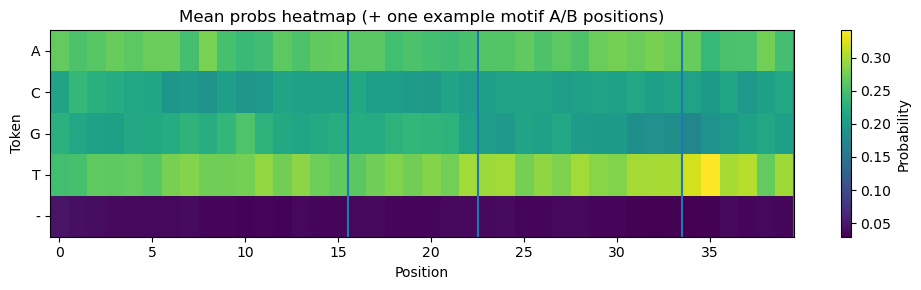

Example sequence: ACAGGG-CGGCGGAGCACTAGGTAGG-TACGAAGATCTTA
motif A start: 16 motif B start: 34


In [29]:
# --- Optional: overlay one example's motif locations (for intuition) ---
def find_motif_pos(seq, motif):
    return seq.find(motif)


# pick one sequence that contains both motifs
example_seq = None
for s in seqs:
    pa = find_motif_pos(s, motif_a)
    pb = find_motif_pos(s, motif_b)
    if pa >= 0 and pb >= 0:
        example_seq = s
        break

if example_seq is None:
    print("No example found with both motifs.")
else:
    pa = find_motif_pos(example_seq, motif_a)
    pb = find_motif_pos(example_seq, motif_b)

    plt.figure(figsize=(10, 3))
    plt.imshow(heat.T, aspect="auto")
    plt.title("Mean probs heatmap (+ one example motif A/B positions)")
    plt.xlabel("Position")
    plt.ylabel("Token")
    plt.yticks(range(len(VOCAB_CHS)), VOCAB_CHS)
    plt.xticks(range(0, SEQ_LEN, 5))
    plt.colorbar(label="Probability")

    # mark motif A range
    plt.axvline(pa - 0.5)
    plt.axvline(pa + len(motif_a) - 0.5)

    # mark motif B range
    plt.axvline(pb - 0.5)
    plt.axvline(pb + len(motif_b) - 0.5)

    plt.tight_layout()
    plt.show()

    print("Example sequence:", example_seq)
    print("motif A start:", pa, "motif B start:", pb)

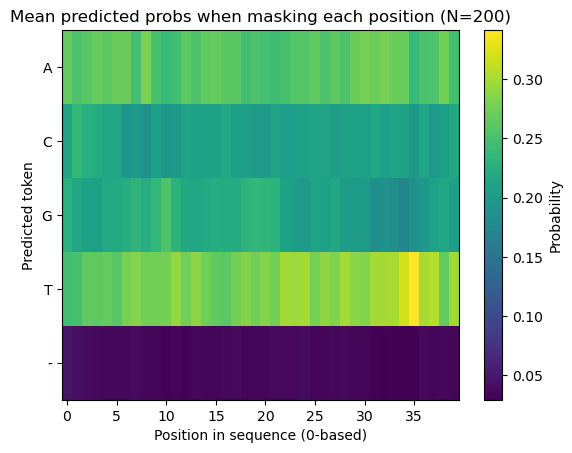

In [22]:
plt.figure()
plt.imshow(heat.T, aspect="auto")  # transpose -> y=token, x=position
plt.yticks(range(len(VOCAB_CHS)), VOCAB_CHS)
plt.xticks(range(0, SEQ_LEN, 5))
plt.xlabel("Position in sequence (0-based)")
plt.ylabel("Predicted token")
plt.title("Mean predicted probs when masking each position (N=200)")
plt.colorbar(label="Probability")
plt.show()

In [30]:
from collections import Counter

import numpy as np


def find_motif_pos(seq, motif):
    return seq.find(motif)


# collect motif B start positions
b_pos = [find_motif_pos(s, motif_b) for s in seqs]
b_pos = [p for p in b_pos if p >= 0]

print("Total sequences:", len(seqs))
print("Sequences containing motif B:", len(b_pos))

pos_counts = Counter(b_pos)
print("Unique motif B start positions:", len(pos_counts))

# show top positions
for p, c in pos_counts.most_common(10):
    print(f"b_start={p:2d}  count={c}")

# (optional) pick a few positions to visualize later
top_positions = [p for p, c in pos_counts.most_common(4)]
print("Top positions:", top_positions)

Total sequences: 2000
Sequences containing motif B: 1387
Unique motif B start positions: 35
b_start=34  count=109
b_start=31  count=102
b_start=32  count=100
b_start=33  count=95
b_start=30  count=80
b_start=28  count=70
b_start=27  count=60
b_start=29  count=53
b_start=23  count=51
b_start=25  count=48
Top positions: [34, 31, 32, 33]


In [31]:
def group_seqs_by_bstart(seqs, motif_b, b_start):
    out = []
    for s in seqs:
        if s.find(motif_b) == b_start:
            out.append(s)
    return out


# choose one b_start to plot (change this)
B_START = top_positions[0] if len(top_positions) > 0 else 0

group = group_seqs_by_bstart(seqs, motif_b, B_START)
print(f"Selected b_start={B_START}, group size={len(group)}")

# limit group size for speed (optional)
N_USE = min(len(group), 500)
group_subset = group[:N_USE]

heat_group = mean_probs_heatmap(group_subset)
print("heat_group shape:", heat_group.shape)

Selected b_start=34, group size=109
done 10/40
done 20/40
done 30/40
done 40/40
heat_group shape: (40, 5)


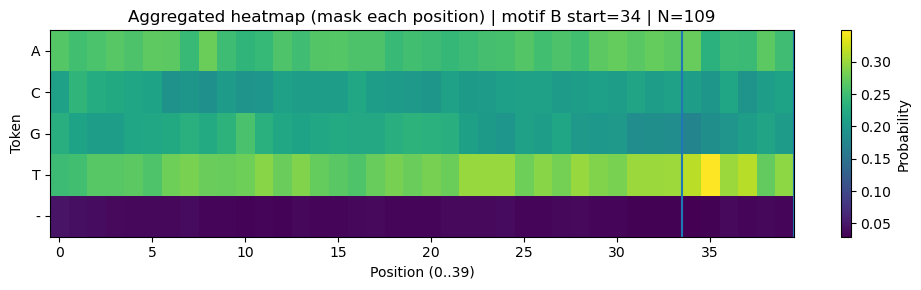

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))
plt.imshow(heat_group.T, aspect="auto")
plt.title(
    f"Aggregated heatmap (mask each position) | motif B start={B_START} | N={len(group_subset)}"
)
plt.xlabel("Position (0..39)")
plt.ylabel("Token")
plt.yticks(range(len(VOCAB_CHS)), VOCAB_CHS)
plt.xticks(range(0, SEQ_LEN, 5))
plt.colorbar(label="Probability")

# mark motif B region
plt.axvline(B_START - 0.5)
plt.axvline(B_START + len(motif_b) - 0.5)

plt.tight_layout()
plt.show()

Ground-truth freq computed on N = 109


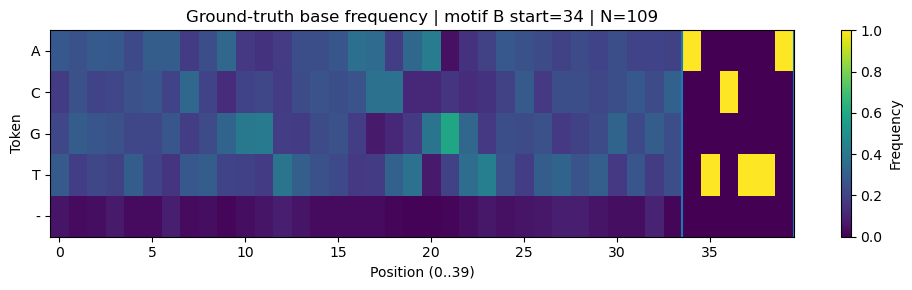

In [33]:
import matplotlib.pyplot as plt
import numpy as np

SEQ_LEN = 40
VOCAB_CHS = ["A", "C", "G", "T", "-"]
ch2i = {ch: i for i, ch in enumerate(VOCAB_CHS)}


def empirical_freq_heatmap(seqs_subset, seq_len=SEQ_LEN):
    """
    Compute empirical base frequencies (ground truth) per position.
    Returns: [seq_len, 5] where each row sums to 1 (if no invalid chars).
    """
    counts = np.zeros((seq_len, len(VOCAB_CHS)), dtype=np.float64)
    n = 0

    for s in seqs_subset:
        if len(s) < seq_len:
            continue
        n += 1
        for pos in range(seq_len):
            ch = s[pos]
            if ch in ch2i:
                counts[pos, ch2i[ch]] += 1

    freqs = counts / max(n, 1)
    return freqs, n


# choose same group as your heatmap (recommended for apples-to-apples)
gt_freq, n_used = empirical_freq_heatmap(group_subset, seq_len=SEQ_LEN)
print("Ground-truth freq computed on N =", n_used)

plt.figure(figsize=(10, 3))
plt.imshow(gt_freq.T, aspect="auto")
plt.title(f"Ground-truth base frequency | motif B start={B_START} | N={n_used}")
plt.xlabel("Position (0..39)")
plt.ylabel("Token")
plt.yticks(range(len(VOCAB_CHS)), VOCAB_CHS)
plt.xticks(range(0, SEQ_LEN, 5))
plt.colorbar(label="Frequency")

# mark motif B region
plt.axvline(B_START - 0.5)
plt.axvline(B_START + len(motif_b) - 0.5)

plt.tight_layout()
plt.show()

In [34]:
import numpy as np
import torch
import torch.nn.functional as F

SEQ_LEN = 40
MAX_LEN = 64
BATCH_SIZE = 32

mask_id = tokenizer.mask_token_id

# token ids for A/C/G/T (query substitutions)
A_id = tokenizer("A")["input_ids"][0][1]
C_id = tokenizer("C")["input_ids"][0][1]
G_id = tokenizer("G")["input_ids"][0][1]
T_id = tokenizer("T")["input_ids"][0][1]
DNA_IDS = torch.tensor([A_id, C_id, G_id, T_id], device=device)
DNA_CHS = ["A", "C", "G", "T"]


def dependency_map_substitution(seqs_subset, batch_size=BATCH_SIZE):
    """
    D[i,j] = max_s | logP(true_j | original, mask j) - logP(true_j | mutate i->s, mask j) |
    where s runs over A/C/G/T excluding original base at i.
    """
    model.eval()
    N = len(seqs_subset)
    D = np.zeros((SEQ_LEN, SEQ_LEN), dtype=np.float64)

    # tokenize once
    enc = tokenizer(seqs_subset, MAX_LEN, padding="max_length", return_tensors="pt")
    input_ids0 = enc["input_ids"].to(device)  # [N, L]
    attn0 = enc["attention_mask"].to(device)

    # true token ids at each char position (shift +1 for CLS)
    true_ids = input_ids0[:, 1 : 1 + SEQ_LEN]  # [N, SEQ_LEN]

    # helper to get logP(true_j) when j is masked (optionally with i mutated)
    def batch_logp_truej(ids_batch, attn_batch, truej_ids_batch, j_char):
        """
        ids_batch: [B,L]
        truej_ids_batch: [B]  (true token id at position j)
        returns: logP(true_j) [B]
        """
        j_tok = j_char + 1
        with torch.no_grad():
            out = model(input_ids=ids_batch, attention_mask=attn_batch)
        logits = out.logits if hasattr(out, "logits") else out[0]  # [B,L,V]
        logp = torch.log_softmax(logits[:, j_tok, :], dim=-1)  # [B,V]
        return logp.gather(1, truej_ids_batch.unsqueeze(1)).squeeze(1)  # [B]

    # loop over target j (mask position)
    for j in range(SEQ_LEN):
        # baseline: mask j only
        base_logps = []

        for s in range(0, N, batch_size):
            ids = input_ids0[s : s + batch_size].clone()
            attn = attn0[s : s + batch_size]
            truej = true_ids[s : s + batch_size, j]

            j_tok = j + 1
            ids[:, j_tok] = mask_id  # mask target

            lp = batch_logp_truej(ids, attn, truej, j_char=j)
            base_logps.append(lp.detach().cpu())

        base_logps = torch.cat(base_logps, dim=0)  # [N]

        # loop over query i
        for i in range(SEQ_LEN):
            # if i == j, skip or allow (usually skip)
            if i == j:
                D[i, j] = 0.0
                continue

            # compute max over substitutions
            max_delta = None

            for alt_id in DNA_IDS:
                deltas = []

                for s in range(0, N, batch_size):
                    ids = input_ids0[s : s + batch_size].clone()
                    attn = attn0[s : s + batch_size]
                    truej = true_ids[s : s + batch_size, j]

                    # skip sequences where query i is not A/C/G/T (e.g., gap)
                    qi = true_ids[s : s + batch_size, i]  # [B]
                    # only keep rows where qi is in DNA_IDS
                    is_dna = (qi.unsqueeze(1) == DNA_IDS.unsqueeze(0)).any(dim=1)

                    if not is_dna.any():
                        continue

                    # apply target mask
                    ids[:, j + 1] = mask_id

                    # mutate query i to alt, but only for rows where:
                    # 1) query is DNA
                    # 2) alt != original
                    orig_tok = ids[:, i + 1]
                    can_mut = is_dna & (orig_tok != alt_id)

                    ids[can_mut, i + 1] = alt_id

                    lp_mut = batch_logp_truej(ids, attn, truej, j_char=j).detach().cpu()
                    # delta only meaningful for rows we actually mutated
                    delta = (base_logps[s : s + batch_size] - lp_mut).abs()
                    delta = delta[can_mut.cpu()]

                    if len(delta) > 0:
                        deltas.append(delta)

                if len(deltas) == 0:
                    continue

                deltas = torch.cat(deltas, dim=0)
                cand = float(deltas.mean().item())

                max_delta = cand if (max_delta is None) else max(max_delta, cand)

            D[i, j] = 0.0 if (max_delta is None) else max_delta

        if (j + 1) % 5 == 0:
            print(f"done target j {j+1}/{SEQ_LEN}")

    return D

In [36]:
from collections import defaultdict

groups = defaultdict(list)

for s in seqs:
    p = find_motif_pos(s, motif_b)
    if p >= 0:
        groups[p].append(s)

print("Example group sizes:")
for k in sorted(groups)[:5]:
    print(k, len(groups[k]))

Example group sizes:
0 17
1 16
2 18
3 24
4 19


b_start = 34
subset = groups[b_start][:200]  
D = dependency_map_substitution(subset)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.imshow(D, aspect="auto")
plt.colorbar(label="Dependency (substitution)")
plt.xlabel("Target position j")
plt.ylabel("Query position i")
plt.title(f"Substitution dependency map | motif B start={b_start} | n={len(subset)}")
plt.show()

In [38]:
# --- pick one sequence that contains BOTH motifs A and B ---
def find_motif_pos(seq, motif):
    return seq.find(motif)

# motif_a, motif_b가 이미 정의돼 있다고 가정
candidates = []
for s in seqs:
    pa = find_motif_pos(s, motif_a)
    pb = find_motif_pos(s, motif_b)
    if pa >= 0 and pb >= 0:
        candidates.append((s, pa, pb))

print("num candidates (A & B):", len(candidates))

# 하나 선택 (원하면 idx 바꾸면 됨)
idx = 0
s_one, pa, pb = candidates[idx]

print("\nSELECTED SEQ:", s_one)
print("len:", len(s_one))
print("motif A start:", pa, "motif:", motif_a)
print("motif B start:", pb, "motif:", motif_b)

# 보기 좋게 마킹해서 출력
def mark(seq, spans):
    spans = sorted(spans, key=lambda x: x[0])
    out = []
    last = 0
    for st, ln, tag in spans:
        out.append(seq[last:st])
        out.append(f"[{tag}:{seq[st:st+ln]}]")
        last = st + ln
    out.append(seq[last:])
    return "".join(out)

print("marked:", mark(s_one, [(pa, len(motif_a), "A"), (pb, len(motif_b), "B")]))

num candidates (A & B): 754

SELECTED SEQ: ACAGGG-CGGCGGAGCACTAGGTAGG-TACGAAGATCTTA
len: 40
motif A start: 16 motif: ACTAGGT
motif B start: 34 motif: ATCTTA
marked: ACAGGG-CGGCGGAGC[A:ACTAGGT]AGG-TACGAAG[B:ATCTTA]


done target j 5/40
done target j 10/40
done target j 15/40
done target j 20/40
done target j 25/40
done target j 30/40
done target j 35/40
done target j 40/40


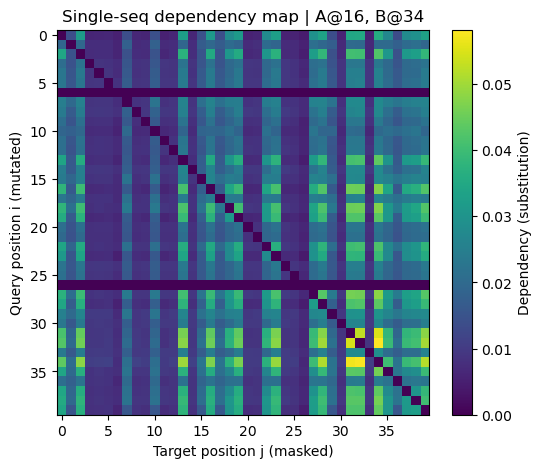

In [39]:
# --- single-seq dependency map ---
subset_one = [s_one]  # N=1 list로 넣어야 함
D_one = dependency_map_substitution(subset_one, batch_size=1)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.imshow(D_one, aspect="auto")
plt.colorbar(label="Dependency (substitution)")
plt.xlabel("Target position j (masked)")
plt.ylabel("Query position i (mutated)")
plt.title(f"Single-seq dependency map | A@{pa}, B@{pb}")
plt.show()

Num (A_start, B_start) groups: 92
Top 10 groups:
(A=17, B=34)  count=30
(A=15, B=32)  count=29
(A=13, B=30)  count=27
(A=14, B=31)  count=26
(A=16, B=33)  count=25
(A=16, B=34)  count=24
(A=14, B=32)  count=22
(A= 8, B=25)  count=20
(A=13, B=31)  count=20
(A= 6, B=23)  count=19

Running group (A=17, B=34) | using n=30 / total=30
done target j 5/40
done target j 10/40
done target j 15/40
done target j 20/40
done target j 25/40
done target j 30/40
done target j 35/40
done target j 40/40


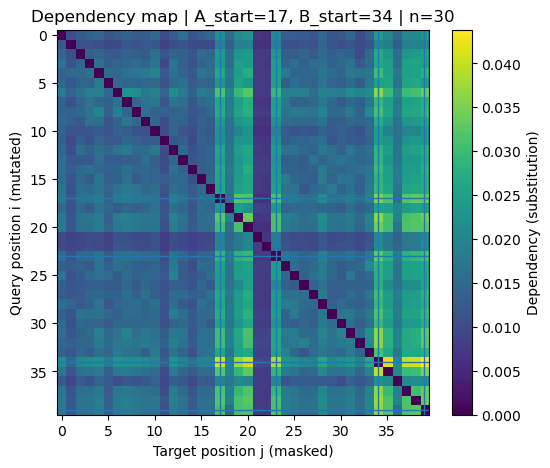


Running group (A=15, B=32) | using n=29 / total=29
done target j 5/40
done target j 10/40
done target j 15/40
done target j 20/40
done target j 25/40
done target j 30/40
done target j 35/40
done target j 40/40


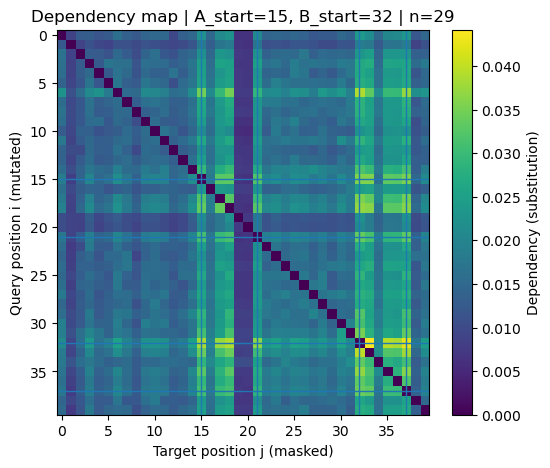


Running group (A=13, B=30) | using n=27 / total=27
done target j 5/40
done target j 10/40
done target j 15/40
done target j 20/40
done target j 25/40
done target j 30/40
done target j 35/40
done target j 40/40


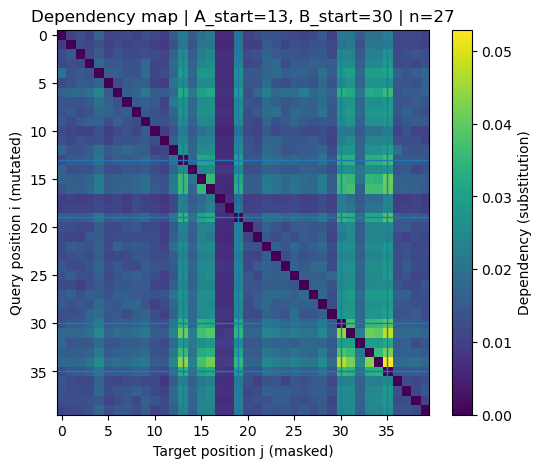


Running group (A=14, B=31) | using n=26 / total=26
done target j 5/40
done target j 10/40
done target j 15/40
done target j 20/40
done target j 25/40
done target j 30/40
done target j 35/40
done target j 40/40


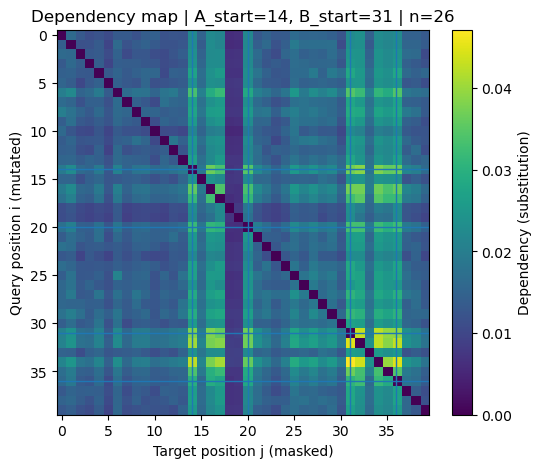

In [40]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

def find_motif_pos(seq, motif):
    return seq.find(motif)

# 1) Build groups by (A_start, B_start)
groups_ab = defaultdict(list)

for s in seqs:
    pa = find_motif_pos(s, motif_a)
    pb = find_motif_pos(s, motif_b)

    # keep only sequences where BOTH motifs exist
    if pa >= 0 and pb >= 0:
        # optional: enforce order (B after A). If you don't want it, remove this line.
        if pb <= pa:
            continue
        groups_ab[(pa, pb)].append(s)

print("Num (A_start, B_start) groups:", len(groups_ab))

# show top groups
counts = sorted([(k, len(v)) for k, v in groups_ab.items()], key=lambda x: x[1], reverse=True)
print("Top 10 groups:")
for (pa, pb), c in counts[:10]:
    print(f"(A={pa:2d}, B={pb:2d})  count={c}")

# 2) Pick top-k groups and plot dependency maps
TOP_K = 4
N_PER_GROUP = 200   # start small (100~200). can increase later.

top_groups = counts[:TOP_K]

a_len = len(motif_a)
b_len = len(motif_b)

for (pa, pb), total_c in top_groups:
    subset = groups_ab[(pa, pb)][:N_PER_GROUP]
    print(f"\nRunning group (A={pa}, B={pb}) | using n={len(subset)} / total={total_c}")

    D = dependency_map_substitution(subset, batch_size=32)

    plt.figure(figsize=(6,5))
    plt.imshow(D, aspect="auto")
    plt.colorbar(label="Dependency (substitution)")
    plt.xlabel("Target position j (masked)")
    plt.ylabel("Query position i (mutated)")
    plt.title(f"Dependency map | A_start={pa}, B_start={pb} | n={len(subset)}")

    # --- mark motif A & B spans on both axes ---
    # vertical = target j
    plt.axvline(pa, linewidth=1)
    plt.axvline(pa + a_len - 1, linewidth=1)
    plt.axvline(pb, linewidth=1)
    plt.axvline(pb + b_len - 1, linewidth=1)

    # horizontal = query i
    plt.axhline(pa, linewidth=1)
    plt.axhline(pa + a_len - 1, linewidth=1)
    plt.axhline(pb, linewidth=1)
    plt.axhline(pb + b_len - 1, linewidth=1)

    plt.show()

Total B-centered windows available: 586
Window length: 21
Example window: AATGAATATCTTATCACACCC
Using subset size: 200
done target j 5/40
done target j 10/40
done target j 15/40
done target j 20/40
done target j 25/40
done target j 30/40
done target j 35/40
done target j 40/40


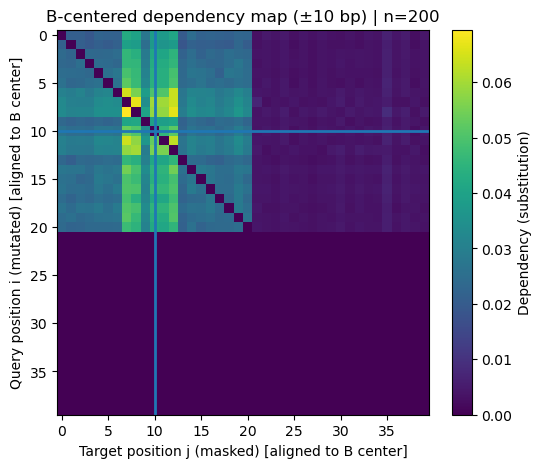

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import random


LEFT = 10
RIGHT = 10
WIN_LEN = LEFT + RIGHT + 1
N_USE = 200          # <-- final sample size

random.seed(0)

def extract_B_center_window(seq: str, motif_b: str, left: int = LEFT, right: int = RIGHT):
    """
    English:
      Find motif_b in seq, take a window centered at motif B center.
      Return substring of length (left+right+1).
      If out of bounds or motif not found, return None.
    """
    b_start = seq.find(motif_b)
    if b_start < 0:
        return None

    b_center = b_start + (len(motif_b) // 2)  # center index in raw string
    L = b_center - left
    R = b_center + right

    if L < 0 or R >= len(seq):
        return None

    return seq[L:R+1]

# 1) Collect aligned windows from ALL sequences
windows = []
for s in seqs:
    w = extract_B_center_window(s, motif_b, left=LEFT, right=RIGHT)
    if w is not None:
        windows.append(w)

print("Total B-centered windows available:", len(windows))
print("Window length:", len(windows[0]) if windows else None)

# Quick sanity check
if windows:
    print("Example window:", windows[0])

# 2) Sample N_USE windows (random) for efficiency
if len(windows) < N_USE:
    print(f"[WARN] Only {len(windows)} windows available; using all of them.")
    subset = windows
else:
    subset = random.sample(windows, N_USE)

print("Using subset size:", len(subset))

# 3) Compute dependency map on the aligned subset
D_Bcenter = dependency_map_substitution(subset, batch_size=BATCH_SIZE)

# 4) Plot heatmap
plt.figure(figsize=(6,5))
plt.imshow(D_Bcenter, aspect="auto")
plt.colorbar(label="Dependency (substitution)")
plt.xlabel("Target position j (masked) [aligned to B center]")
plt.ylabel("Query position i (mutated) [aligned to B center]")
plt.title(f"B-centered dependency map (±{LEFT} bp) | n={len(subset)}")

# Mark the aligned center (B center is at index LEFT in the window)
plt.axvline(LEFT, linewidth=2)
plt.axhline(LEFT, linewidth=2)

plt.show()

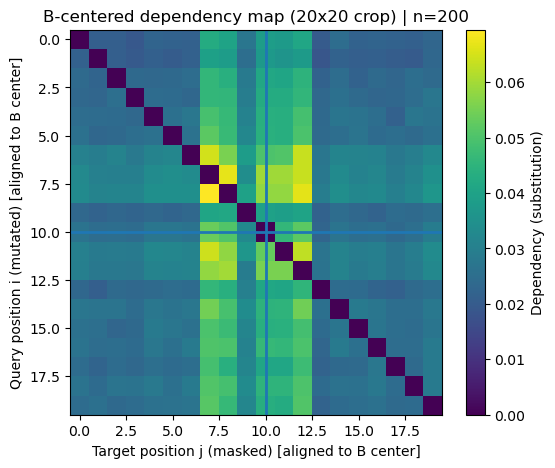

In [48]:
import matplotlib.pyplot as plt

# ---- crop to 20x20 without recomputing ----
D20 = D_Bcenter[:20, :20]   # drop the last row/col (from 21 -> 20)

plt.figure(figsize=(6,5))
plt.imshow(D20, aspect="auto")
plt.colorbar(label="Dependency (substitution)")
plt.xlabel("Target position j (masked) [aligned to B center]")
plt.ylabel("Query position i (mutated) [aligned to B center]")
plt.title("B-centered dependency map (20x20 crop) | n=200")

# In the 21x21 plot, center is at index LEFT=10.
# After cropping to 20, center is still at 10 (valid index).
plt.axvline(LEFT, linewidth=2)
plt.axhline(LEFT, linewidth=2)

plt.show()

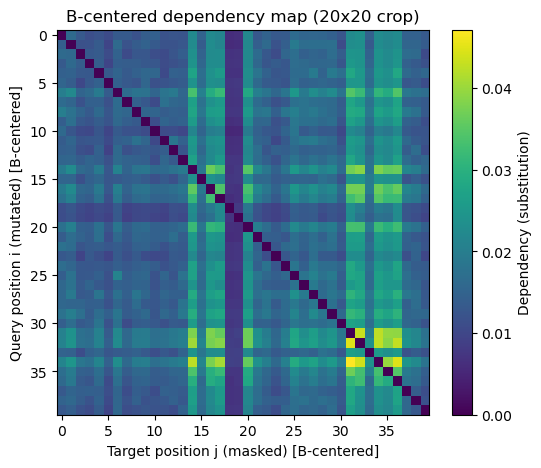

In [47]:
import matplotlib.pyplot as plt



D20 = D[:40, :40]

plt.figure(figsize=(6,5))
plt.imshow(D20, aspect="auto")
plt.colorbar(label="Dependency (substitution)")
plt.xlabel("Target position j (masked) [B-centered]")
plt.ylabel("Query position i (mutated) [B-centered]")
plt.title("B-centered dependency map (20x20 crop)")
plt.show()